In [11]:
# %%
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)


In [12]:
# %%
# Load master panel from processed directory
processed_dir = '../data/processed' if os.path.exists('../data/processed') else '.'
master_path = os.path.join(processed_dir, 'backtest_master_panel.parquet')

df = pd.read_parquet(master_path)

# Ensure proper datetime parsing for Unix millisecond timestamps
for col in ['rebalance_date', 'snapshot_date']:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = pd.to_datetime(df[col], unit='ms')

print(f"Dataset successfully loaded: {len(df):,} total row entries.")
df.head()

Dataset successfully loaded: 155,343 total row entries.


,rebalance_date,snapshot_date,ticker,permno,ym,price,ret,dlret,total_return,fwd_return
0,2000-01-31,2000-01-31,JAVA,10078,2000-01,78.5625,0.014528,0.0,0.014528,0.21241
1,2000-01-31,2000-01-31,ORCL,10104,2000-01,49.95313,-0.108477,0.0,-0.108477,0.486393
2,2000-01-31,2000-01-31,MSFT,10107,2000-01,97.875,-0.16167,0.0,-0.16167,-0.086846
3,2000-01-31,2000-01-31,TROW,10138,2000-01,38.875,0.052454,0.0,0.052454,-0.152733
4,2000-01-31,2000-01-31,HON,10145,2000-01,48.0,-0.167931,0.0,-0.167931,0.00651


Total Rebalance Dates : 300
Min Constituent Count : 509 on 2013-05-31
Max Constituent Count : 524 on 2002-09-30
Mean Constituent Count: 516.81


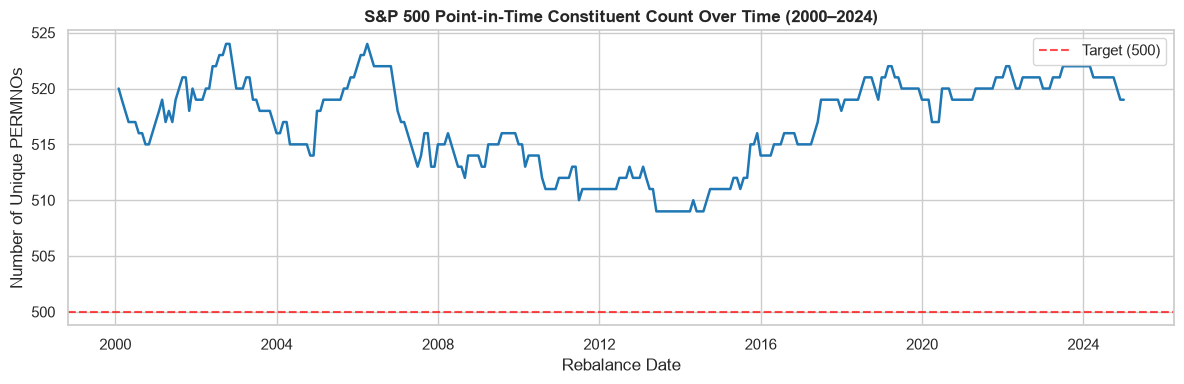

In [13]:
# %%
monthly_counts = df.groupby('rebalance_date')['permno'].nunique()

print(f"Total Rebalance Dates : {len(monthly_counts)}")
print(f"Min Constituent Count : {monthly_counts.min()} on {monthly_counts.idxmin().strftime('%Y-%m-%d')}")
print(f"Max Constituent Count : {monthly_counts.max()} on {monthly_counts.idxmax().strftime('%Y-%m-%d')}")
print(f"Mean Constituent Count: {monthly_counts.mean():.2f}")

# Plot monthly cross-sectional size
plt.figure(figsize=(12, 4))
plt.plot(monthly_counts.index, monthly_counts.values, color='#1f77b4', linewidth=1.8)
plt.axhline(500, color='red', linestyle='--', alpha=0.7, label='Target (500)')
plt.title("S&P 500 Point-in-Time Constituent Count Over Time (2000–2024)", fontsize=12, fontweight='bold')
plt.xlabel("Rebalance Date")
plt.ylabel("Number of Unique PERMNOs")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# %% [markdown]
# ### 3. Check 2: Missing Data & Return Coverage Audit
# Identifies data gaps in historical returns ($R_t$) and forward target returns ($R_{t+1}$).

# %%
total_rows = len(df)
missing_total_ret = df['total_return'].isna().sum()
missing_fwd_ret = df['fwd_return'].isna().sum()

missing_summary = pd.DataFrame({
    'Metric': ['Total Rows', 'Missing total_return (R_t)', 'Missing fwd_return (R_t+1)'],
    'Count': [total_rows, missing_total_ret, missing_fwd_ret],
    'Percentage': [100.0, (missing_total_ret / total_rows) * 100, (missing_fwd_ret / total_rows) * 100]
})

print("=== MISSING DATA SUMMARY ===")
print(missing_summary.to_string(index=False))


=== MISSING DATA SUMMARY ===
                    Metric  Count  Percentage
                Total Rows 155343  100.000000
Missing total_return (R_t)    301    0.193765
Missing fwd_return (R_t+1)    893    0.574857


=== RETURN & PRICE DISTRIBUTION STATISTICS ===
           price  total_return  fwd_return
count   154756.0      155042.0    154450.0
mean     83.6616        0.0097      0.0097
std      181.604        0.1023      0.1023
min        0.075       -0.9761     -0.9761
0.1%      0.5617       -0.4916     -0.4983
1%        3.4255       -0.2642     -0.2646
5%         10.63       -0.1415     -0.1408
50%        48.84        0.0099      0.0099
95%     247.3275        0.1568      0.1565
99%      575.019        0.2912       0.291
99.9%  2478.2545        0.6342      0.6358
max    9811.7998        2.8667      2.8667


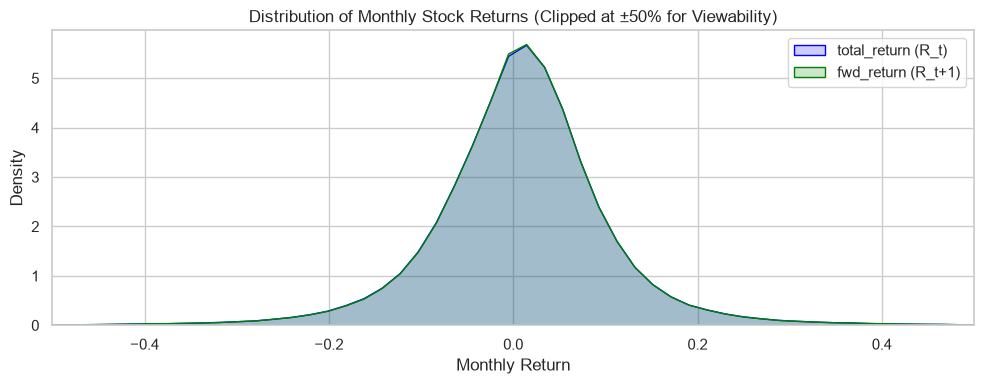

In [15]:
# %% [markdown]
# ### 4. Check 3: Return Distribution & Extreme Outliers
# Evaluates summary statistics and percentiles to check for erroneous price spikes or unadjusted splits.

# %%
ret_stats = df[['price', 'total_return', 'fwd_return']].describe(
    percentiles=[0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]
)
print("=== RETURN & PRICE DISTRIBUTION STATISTICS ===")
print(ret_stats.round(4).to_string())

# Density distribution plot of returns
plt.figure(figsize=(10, 4))
sns.kdeplot(df['total_return'].dropna(), label='total_return (R_t)', color='blue', fill=True, alpha=0.2)
sns.kdeplot(df['fwd_return'].dropna(), label='fwd_return (R_t+1)', color='green', fill=True, alpha=0.2)
plt.xlim(-0.5, 0.5)
plt.title("Distribution of Monthly Stock Returns (Clipped at ±50% for Viewability)")
plt.xlabel("Monthly Return")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# %% [markdown]
# ### 5. Check 4: Forward Return Alignment Verification
# Validates that $R_{t+1}$ in period $t$ strictly matches $R_t$ in period $t+1$ without lookahead shift errors.

# %%
# Select the most frequent PERMNO in the dataset for deterministic verification
sample_permno = df['permno'].value_counts().index[0]
sample_df = df[df['permno'] == sample_permno].sort_values('rebalance_date').reset_index(drop=True)

# Shift total_return by -1 to get the actual t+1 return
sample_df['next_total_return'] = sample_df['total_return'].shift(-1)

# Drop the last row since t+1 doesn't exist for the final rebalance date
check_df = sample_df.dropna(subset=['fwd_return', 'next_total_return']).copy()

# Element-wise array comparison using numpy
is_aligned = np.isclose(check_df['fwd_return'].to_numpy(), check_df['next_total_return'].to_numpy(), equal_nan=True)
match_rate = is_aligned.mean() if len(is_aligned) > 0 else 0.0

print(f"Forward Return Shift Match Rate for PERMNO {sample_permno}: {match_rate:.2%}")

if match_rate == 1.0:
    print("✓ PASS: fwd_return strictly aligns with t+1 total_return.")
else:
    print("⚠️ ALERT: Lead/Lag mismatch detected in forward return logic.")

# Display inspection slice using plain Pandas printing to prevent display() errors
print("\nInspection Slice (First 10 Rows):")
print(sample_df[['rebalance_date', 'ticker', 'permno', 'total_return', 'fwd_return', 'next_total_return']].head(10).to_string(index=False))

# %% [markdown]
# ### 6. Check 5: Delisting Return Integration Audit
# Confirms that terminal delisting returns (`dlret`) are recorded to eliminate survivorship bias.

# %%
# Audit non-zero delisting returns
delist_events = df[df['dlret'].notna() & (df['dlret'] != 0)]

print("=== SURVIVORSHIP / DELISTING AUDIT ===")
print(f"Total Non-Zero Delisting Events Captured: {len(delist_events):,}")

if len(delist_events) > 0:
    print(f"Minimum Delisting Return               : {df['dlret'].min():.2%}")
    print(f"Mean Delisting Return (when present)   : {delist_events['dlret'].mean():.2%}")
    print("\nSample Captured Delisting Events:")
    print(delist_events[['rebalance_date', 'ticker', 'permno', 'ret', 'dlret', 'total_return']].head().to_string(index=False))
else:
    print("⚠️ ALERT: No delisting returns found in the panel.")

Forward Return Shift Match Rate for PERMNO 10104: 100.00%
✓ PASS: fwd_return strictly aligns with t+1 total_return.

Inspection Slice (First 10 Rows):
rebalance_date ticker  permno  total_return  fwd_return  next_total_return
    2000-01-31   ORCL   10104     -0.108477    0.486393           0.486393
    2000-02-29   ORCL   10104      0.486393    0.051347           0.051347
    2000-03-31   ORCL   10104      0.051347    0.024019           0.024019
    2000-04-30   ORCL   10104      0.024019    -0.10086           -0.10086
    2000-05-31   ORCL   10104      -0.10086    0.169565           0.169565
    2000-06-30   ORCL   10104      0.169565   -0.105576          -0.105576
    2000-07-31   ORCL   10104     -0.105576    0.209476           0.209476
    2000-08-31   ORCL   10104      0.209476   -0.134021          -0.134021
    2000-09-30   ORCL   10104     -0.134021   -0.161905          -0.161905
    2000-10-31   ORCL   10104     -0.161905    -0.19697           -0.19697
=== SURVIVORSHIP / DELIS